In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Imports
import torch
import pandas as pd
import os 
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import chisquare

from vae import GroupHardMax
from finetuner import get_matching_indices


In [11]:
group_sizes = [
    2,
    5,
    5,
    11,
    2,
    2,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
]

variables_dict = {
    'TEN': 'Tenure',
    'HHL': 'Household Language',
    'VEH': 'Vehicles avaiable',
    'HINCP': 'Household Income (Thousands of USD)',
    'AGEP': 'Age (in years)',
    'SEX': 'Sex',
    'R65': 'Persons 65 years ≤',
    'R18': 'Persons ≤18 years',
    'SCHL': 'Education',
}


def rmse(arr1, arr2):
    return np.sqrt(((arr1 - arr2)**2).sum()/len(arr1))

def kl(arr1, arr2):
    return np.sum(arr1*np.log(arr1/arr2))
def plot_vars_bars(marginals, predicted_marginals, state_marginals, variables, legend=False, figsize= (10,5), bbox_to_anchor = (1,1), img_name = None):
    num_keys_per_variable = []
    num_keys = 0
    for v in variables:
        # Count how many keys match v
        keys_v = [k for k in predicted_marginals.keys() if k.startswith(v)]
        num_keys_per_variable.append(len(keys_v))
        num_keys += len(keys_v)

    fig = plt.figure(figsize=figsize)  # Overall size; adjust as needed

    # Create a 1-row, len(variables)-column grid,
    # with column widths proportional to the number of categories
    gs = GridSpec(1, len(variables), width_ratios=num_keys_per_variable, wspace=0.2)

    axes = []
    for i in range(len(variables)):
        if i == 0:
            ax = fig.add_subplot(gs[i])  # first subplot
        else:
            ax = fig.add_subplot(gs[i])
            ax.sharey(axes[0])          # share y-axis with first subplot
        axes.append(ax)

    for i, v in enumerate(variables):
        ax = axes[i]
        
        # Get keys & data
        keys = [k for k in marginals.keys() if k.startswith(v)]
        state_marginals_v = [state_marginals[k] for k in keys]
        pred_marginals_v  = [predicted_marginals[k] for k in keys]
        gt_marginals_v    = [marginals[k] for k in keys]

        # Renormalise marginals due to small numerical imprecision
        pred_marginals_v = [m/sum(pred_marginals_v) for m in pred_marginals_v]
        gt_marginals_v = [m/sum(gt_marginals_v) for m in gt_marginals_v]
        state_marginals_v = [m/sum(state_marginals_v) for m in state_marginals_v]

        # Calculate chi square p value
        if v == 'HHL':
            # Get rid of 'other' category, renormalise
            pred_marginals_sub = pred_marginals_v[:-1]
            gt_marginals_sub = gt_marginals_v[:-1]
            state_marginals_sub = state_marginals_v[:-1]

            pred_marginals_sub = [m/sum(pred_marginals_sub) for m in pred_marginals_sub]
            gt_marginals_sub = [m/sum(gt_marginals_sub) for m in gt_marginals_sub]
            state_marginals_sub = [m/sum(state_marginals_sub) for m in state_marginals_sub]

            _, p_tract = chisquare(pred_marginals_sub, gt_marginals_sub)
            _, p_state = chisquare(state_marginals_sub, gt_marginals_sub)
        else:
            _, p_tract = chisquare(pred_marginals_v, gt_marginals_v)
            _, p_state = chisquare(state_marginals_v, gt_marginals_v)

        # Positions for bars
        x = np.arange(len(keys))
        width = 0.2

        # Plot grouped bars
        axes[i].bar(x,                 state_marginals_v, width=width, label='State Marginals')
        axes[i].bar(x + width,         pred_marginals_v,  width=width, label='Synthetic Marginals')
        axes[i].bar(x + 2 * width,     gt_marginals_v,    width=width, label='Groundtruth Marginals')

        # Plot p value
        if v == 'HHL':
            ax.text(0.99, 0.99, f'P_t = {p_tract:.2f} (Excluding Other)\nP_s = {p_state:.2f} (Excluding Other)', transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=10, color='black')
        else:
            ax.text(0.99, 0.99, f'P_t = {p_tract:.2f}\nP_s = {p_state:.2f}', transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=10, color='black')

        # Nicely align ticks
        axes[i].set_xticks(x + width)
        axes[i].set_xticklabels([k.removeprefix(v + ':') for k in keys], rotation=90)

        # Give the bars a bit of left-right padding
        axes[i].set_xlim([-0.5, len(keys)])

        axes[i].set_title(variables_dict[v])

    if legend:
        fig.legend(*axes[0].get_legend_handles_labels(),
            loc='upper right', bbox_to_anchor=bbox_to_anchor)

    if img_name:
        plt.savefig(f'/workspace/finetune_pngs_dfs/{img_name}')
    plt.show()

def get_marginals(data_table, household_indices, personal_indices, nan_indices):
    n_households = data_table.shape[0]

    marginals = {}
    # Handle household variables
    for var, indices in household_indices.items():
        marginals[var] = data_table[:, indices].mean()

    # Handle personal variables
    n_people_per_household = len(list(personal_indices.values())[0])
    n_people_with_nans = n_people_per_household * n_households

    for var, indices in personal_indices.items():
        matching_nan_variable = var.split(":")[0] + ':' + 'nan' # Eg for SEX:male, matching nan variable is SEX:nan
        n_people = n_people_with_nans - data_table[:, nan_indices[matching_nan_variable]].sum()
        marginals[var] = data_table[:, indices].sum()/n_people

    return marginals

def create_table(marginals, predicted_marginals, state_marginals, file_name):
    RMSEs_baseline = {}
    RMSEs_synth = {}
    KLs_baseline = {}
    KLs_synth = {}

    variables = ['TEN', 'VEH', 'HHL', 'HINCP', 'R18', 'R65', 'AGEP', 'SCHL', 'SEX']
    for v in variables:
        # Get data
        keys = [k for k in marginals.keys() if k.startswith(v)]
        state_marginals_v = [state_marginals    [k] for k in keys]
        pred_marginals_v  = [predicted_marginals[k] for k in keys]
        gt_marginals_v    = [marginals[k] for k in keys]

        # Renormalise marginals due to small numerical imprecision
        pred_marginals_v = np.array([m/sum(pred_marginals_v) for m in pred_marginals_v])
        gt_marginals_v = np.array([m/sum(gt_marginals_v) for m in gt_marginals_v])
        state_marginals_v = np.array([m/sum(state_marginals_v) for m in state_marginals_v])

        if v == 'HHL':
            # Get rid of 'other' category, renormalise
            pred_marginals_v = pred_marginals_v[:-1]
            gt_marginals_v = gt_marginals_v[:-1]
            state_marginals_v = state_marginals_v[:-1]

            pred_marginals_v /= pred_marginals_v.sum()
            gt_marginals_v /= gt_marginals_v.sum()
            state_marginals_v /= state_marginals_v.sum()

        RMSEs_baseline[v] = rmse(state_marginals_v, gt_marginals_v)
        RMSEs_synth[v] = rmse(pred_marginals_v, gt_marginals_v)
        KLs_baseline[v] = kl(state_marginals_v, gt_marginals_v)
        KLs_synth[v] = kl(pred_marginals_v, gt_marginals_v)

    table = pd.DataFrame([RMSEs_baseline, RMSEs_synth, KLs_baseline, KLs_synth], index = ['RMSE Baseline', 'RMSE Syn. HI.', 'KL Baseline', 'KL Syn. HI.'])
    table.to_csv(f'/workspace/finetune_pngs_dfs/{file_name}.csv')
    return table


# Data Handling

In [12]:
# Read state data
# Get pums_data and marginals
data_name = "one_hot_pNaNs_agep.csv"
pums_data = pd.read_csv(f"/workspace/data/{data_name}")
pums_np = pums_data.to_numpy()

# Read marginals
with open("marginals.json") as f:
    marginals = json.load(f)

# Read predictions data and make one-hot
prediction_folder = '/workspace/finetuned_models/predictions/' # Get path

prediction_paths = os.listdir(prediction_folder)
prediction_path = prediction_folder + prediction_paths[0]

predictions_torch = torch.load(prediction_path) # Load
predictions_unchanged = predictions_torch.detach().cpu().numpy()


hardmax = GroupHardMax(group_sizes) # Make one-hot
predictions_onehot = hardmax(predictions_torch)
predictions = predictions_onehot.detach().cpu().numpy()

# Get marginals for predicted, predicted_cheating and state data
household_indices, personal_indices, nan_indices = get_matching_indices(marginals, list(pums_data.columns))

# Get marginal values for the predictions:
predicted_marginals         = get_marginals(predictions, household_indices, personal_indices, nan_indices)
predicted_marginals_cheat   = get_marginals(predictions_unchanged, household_indices, personal_indices, nan_indices)
state_marginals             = get_marginals(pums_np, household_indices, personal_indices, nan_indices)

# Create dir for results
os.makedirs('/workspace/finetune_pngs_dfs', exist_ok = True)

# Recreate Figure 10 and Table

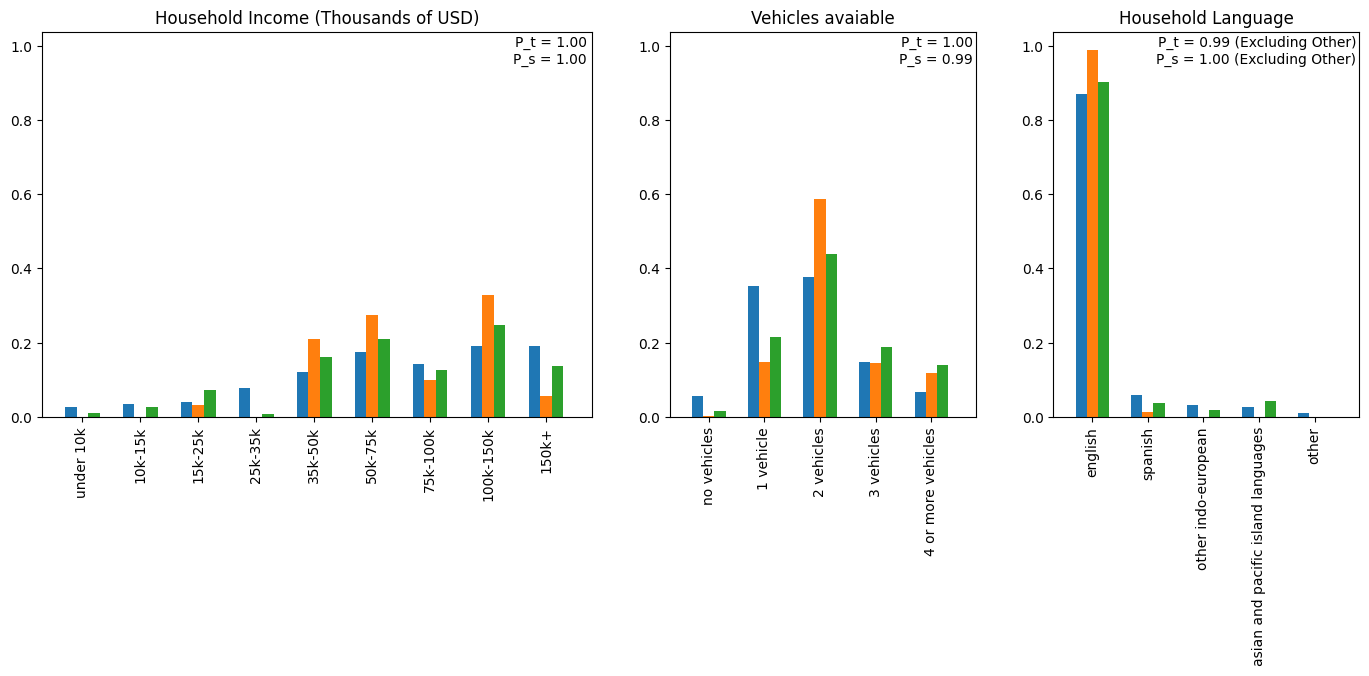

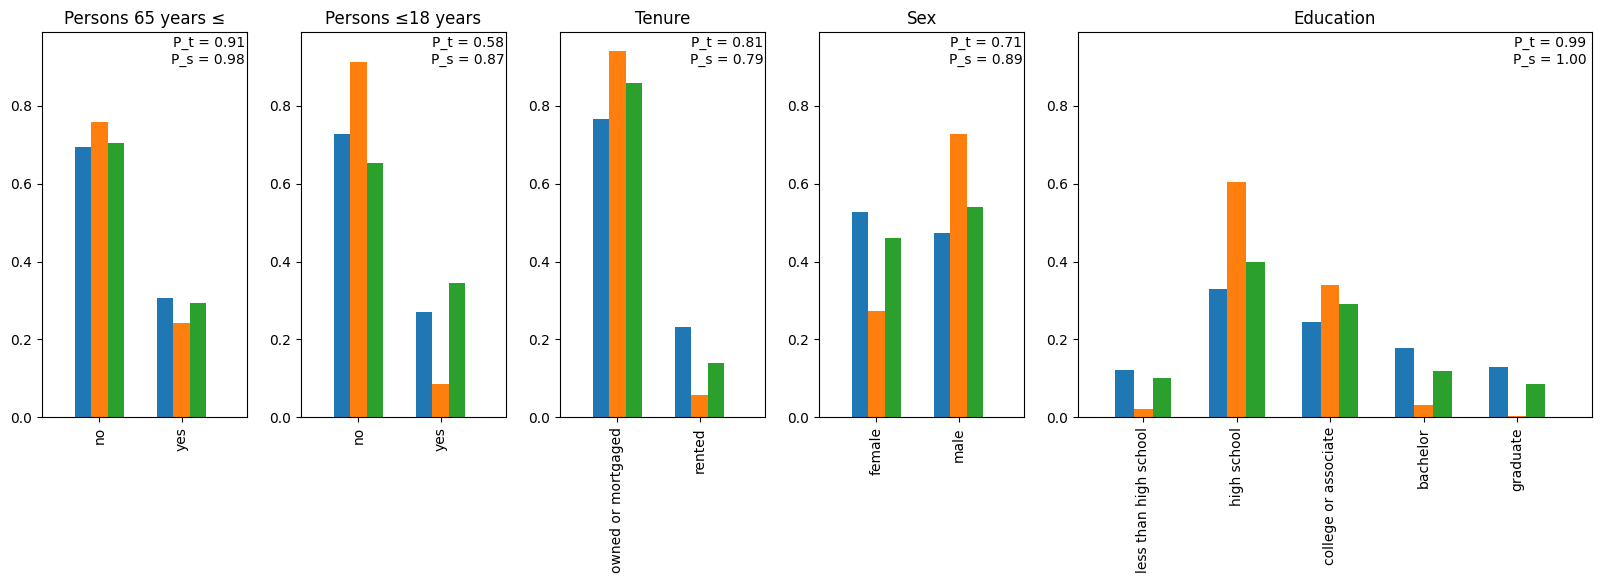

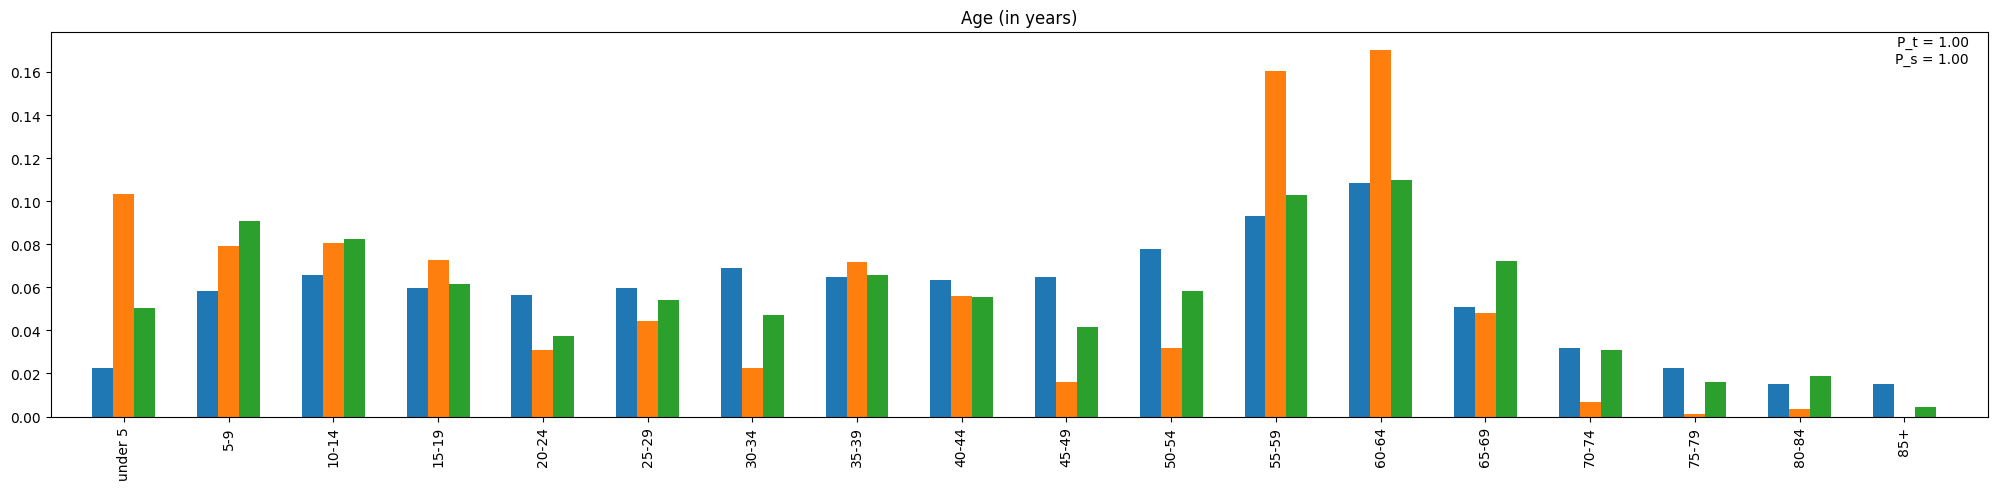

/tmp/ipykernel_31879/1516244245.py:69: RuntimeWarning: divide by zero encountered in log
  return np.sum(arr1*np.log(arr1/arr2))
/tmp/ipykernel_31879/1516244245.py:69: RuntimeWarning: invalid value encountered in multiply
  return np.sum(arr1*np.log(arr1/arr2))


,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.093023,0.078192,0.018878,0.041938,0.074845,0.011026,0.016147,0.050472,0.067852
RMSE Syn. HI.,0.082000,0.075907,0.050748,0.050152,0.259820,0.052558,0.027713,0.114454,0.187206
KL Baseline,0.030924,0.096546,0.014399,0.154434,0.012883,0.000290,0.049367,0.033383,0.009229
KL Syn. HI.,0.034681,0.052061,NaN,NaN,0.186011,0.006907,NaN,0.215603,0.073909


In [ ]:
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['HINCP', 'VEH', 'HHL'], legend=False, figsize = (17,5), img_name = 'plots1')
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'plots2')
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['AGEP'], legend=False, figsize = (25,5), bbox_to_anchor = (0.65, -0.3), img_name = 'plots3')
create_table(marginals, predicted_marginals, state_marginals, 'table4')

## Recreate plots and table (cheating)

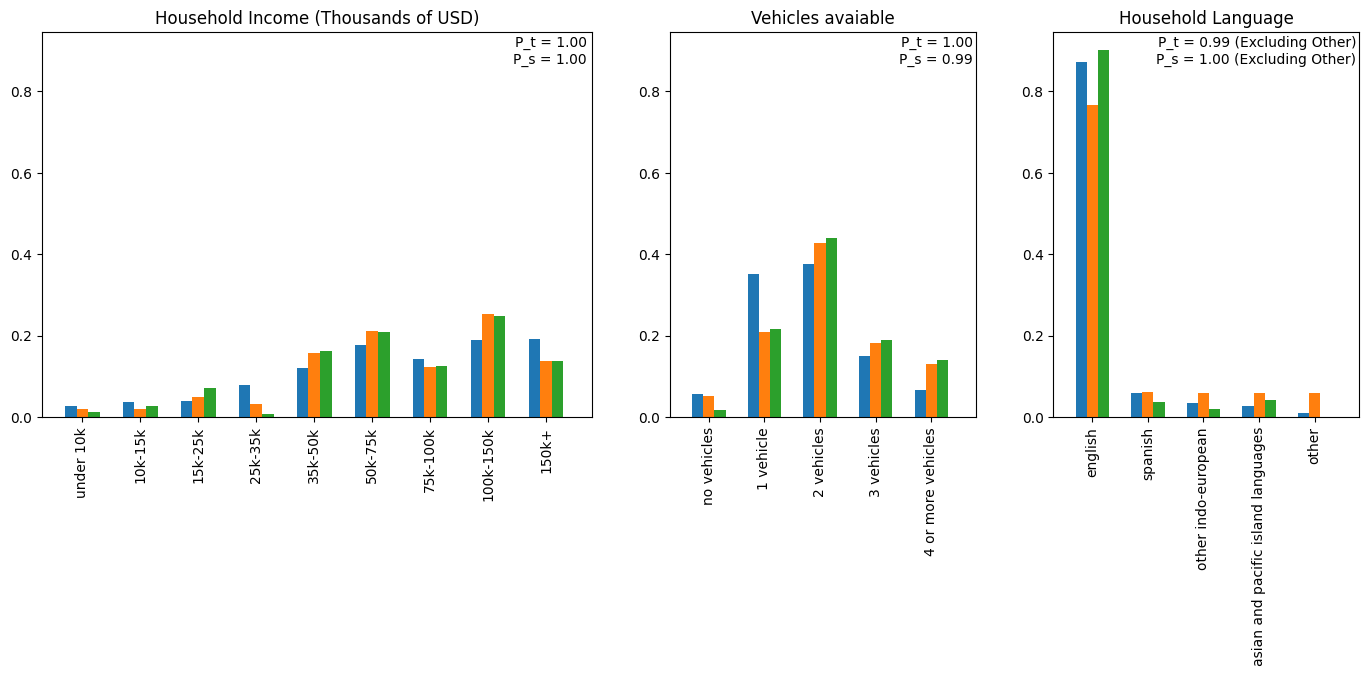

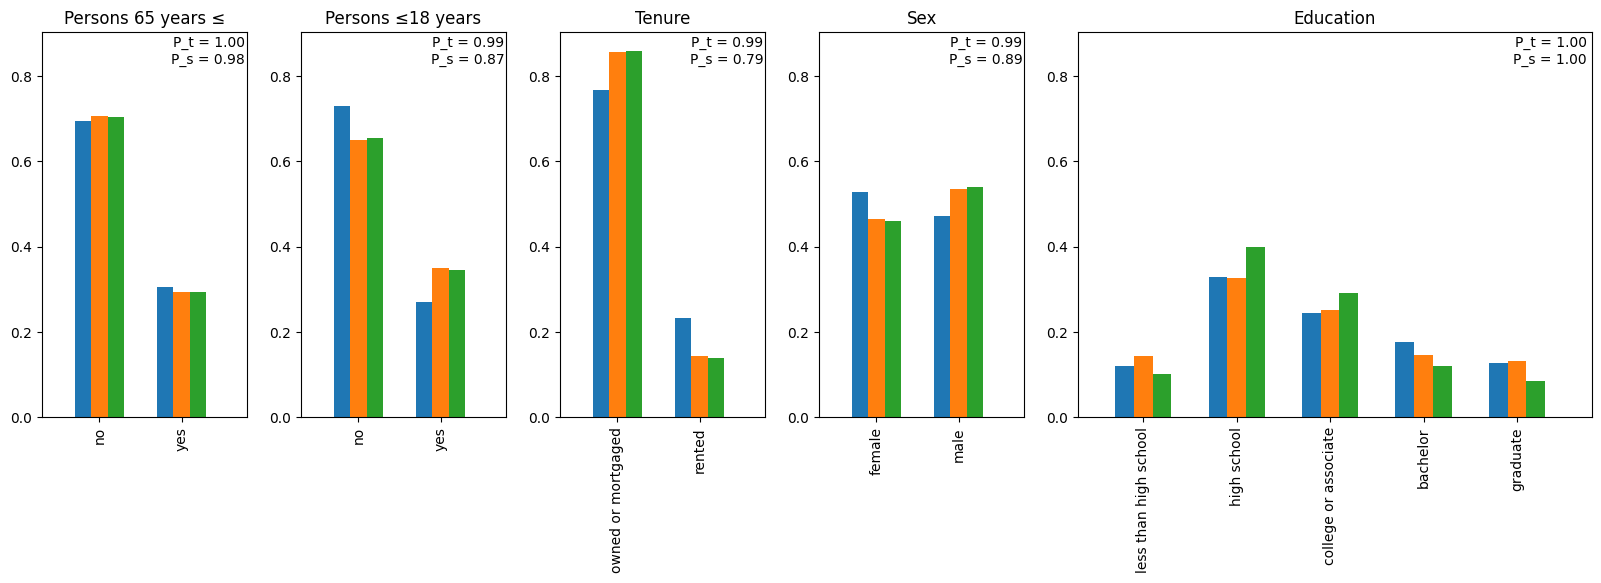

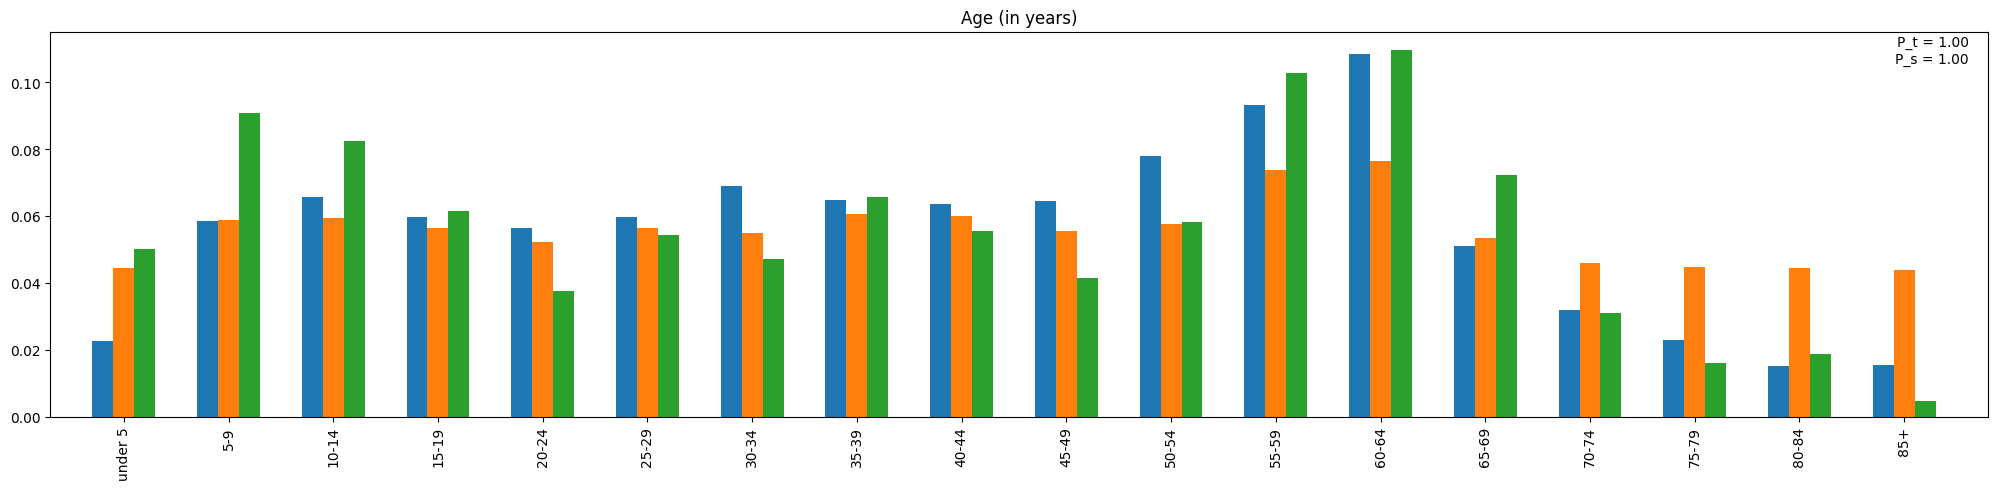

,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.093023,0.078192,0.018878,0.041938,0.074845,1.102633e-02,0.016147,0.050472,0.067852
RMSE Syn. HI.,0.003036,0.017192,0.051878,0.011993,0.004355,5.432886e-04,0.020715,0.048547,0.004668
KL Baseline,0.030924,0.096546,0.014399,0.154434,0.012883,2.904741e-04,0.049367,0.033383,0.009229
KL Syn. HI.,0.000038,0.023045,0.046915,0.028429,0.000042,7.104843e-07,0.122050,0.031584,0.000044


In [ ]:
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['HINCP', 'VEH', 'HHL'], legend=False, figsize = (17,5), img_name = 'plots1_cheat')
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'plots2_cheat')
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['AGEP'], legend=False, figsize = (25,5), bbox_to_anchor = (0.65, -0.3), img_name = 'plots3_cheat')
create_table(marginals, predicted_marginals_cheat, state_marginals, 'table4_cheat')